## XGBoost

XGBoost (Extreme Gradient Boosting) is an ensemble machine learning algorithm based on decision trees.

In this project, XGBoost is used as an additional model to extend the approaches used in the reference paper.

The model will be trained on the training seasons and evaluated on the validation and test seasons using Mean Squared Error (MSE).

In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
model_data = pd.read_csv("../../data/processed/model_features.csv")

print("Dataset loaded!")
print(model_data.shape)

Dataset loaded!
(29575, 41)


In [3]:
train_data = model_data[
    model_data["SEASON"].isin([2012, 2013, 2014, 2015])
].copy()

validation_data = model_data[
    model_data["SEASON"] == 2016
].copy()

test_data = model_data[
    model_data["SEASON"] == 2017
].copy()

print("Training games:", len(train_data))
print("Validation games:", len(validation_data))
print("Testing games:", len(test_data))

Training games: 5681
Validation games: 1405
Testing games: 1382


In [4]:
xgb_features = [
    "HOME_LAST3_POINTS_SCORED",
    "HOME_LAST3_POINTS_ALLOWED",
    "HOME_LAST3_FG_PCT",
    "HOME_LAST3_FT_PCT",
    "HOME_LAST3_FG3_PCT",
    "HOME_LAST3_AST",
    "HOME_LAST3_REB",
    "HOME_LAST3_POINT_DIFFERENTIAL",
    "HOME_DAYS_SINCE_LAST_GAME",
    "AWAY_LAST3_POINTS_SCORED",
    "AWAY_LAST3_POINTS_ALLOWED",
    "AWAY_LAST3_FG_PCT",
    "AWAY_LAST3_FT_PCT",
    "AWAY_LAST3_FG3_PCT",
    "AWAY_LAST3_AST",
    "AWAY_LAST3_REB",
    "AWAY_LAST3_POINT_DIFFERENTIAL",
    "AWAY_DAYS_SINCE_LAST_GAME"
]

X_train = train_data[xgb_features]
y_train = train_data["TOTAL_POINTS"]

X_validation = validation_data[xgb_features]
y_validation = validation_data["TOTAL_POINTS"]

X_test = test_data[xgb_features]
y_test = test_data["TOTAL_POINTS"]

print("Training features:", X_train.shape)
print("Validation features:", X_validation.shape)
print("Test features:", X_test.shape)

Training features: (5681, 18)
Validation features: (1405, 18)
Test features: (1382, 18)


In [5]:
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

print("XGBoost model created!")

XGBoost model created!


In [6]:
xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed!")

XGBoost training completed!


In [7]:
xgb_validation_predictions = xgb_model.predict(X_validation)

print(
    "Number of validation predictions:",
    len(xgb_validation_predictions)
)

print(
    "First 5 predictions:",
    xgb_validation_predictions[:5]
)

Number of validation predictions: 1405
First 5 predictions: [188.43936 193.77052 198.99289 197.95473 193.05402]


In [8]:
xgb_validation_mse = mean_squared_error(
    y_validation,
    xgb_validation_predictions
)

print(
    "XGBoost Validation MSE:",
    round(xgb_validation_mse, 2)
)

XGBoost Validation MSE: 370.32


In [9]:
xgb_test_predictions = xgb_model.predict(X_test)

print(
    "Number of test predictions:",
    len(xgb_test_predictions)
)

print(
    "First 5 predictions:",
    xgb_test_predictions[:5]
)

Number of test predictions: 1382
First 5 predictions: [201.35144 198.47581 191.16821 195.96228 195.18828]


In [10]:
xgb_test_mse = mean_squared_error(
    y_test,
    xgb_test_predictions
)

print(
    "XGBoost Test MSE:",
    round(xgb_test_mse, 2)
)

XGBoost Test MSE: 382.39


In [12]:
comparison = pd.DataFrame({
    "Model": [
        "Collaborative Filtering (SVD)",
        "LSTM",
        "XGBoost"
    ],
    "Test MSE": [
        554.48,
        403.13,
        382.39
    ]
})

comparison = comparison.sort_values(
    by="Test MSE"
).reset_index(drop=True)

print(comparison)

                           Model  Test MSE
0                        XGBoost    382.39
1                           LSTM    403.13
2  Collaborative Filtering (SVD)    554.48


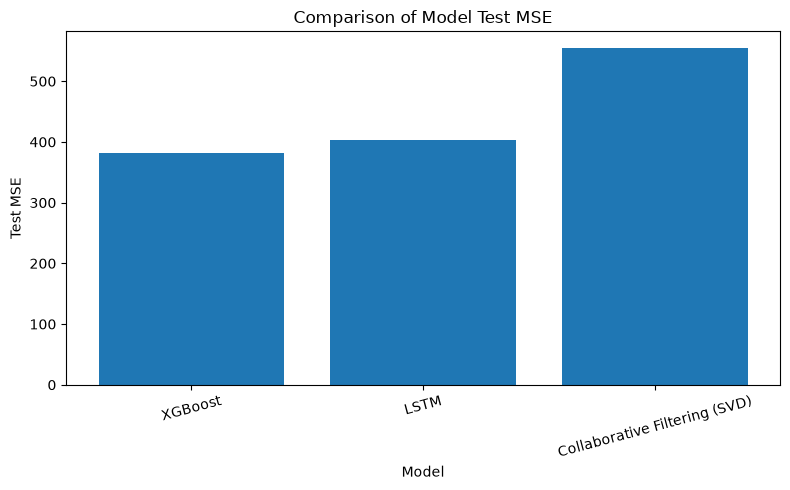

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Test MSE"]
)

plt.xlabel("Model")
plt.ylabel("Test MSE")
plt.title("Comparison of Model Test MSE")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()